# Russian KWS


In [8]:
from pathlib import Path
import sys, os, json, subprocess, hashlib, zipfile, tempfile, stat, csv
import torch
from datetime import datetime, timezone
from uuid import uuid4

REPO_URL = "https://github.com/mole88/ru-kws.git"
REPO_REF = "dev"  # Use a commit SHA for reproducibility.
DATASET_ZIP = Path("/content/drive/MyDrive/russian_commands/russian_commands_v001_clean_manual_with_aug.zip")

RUN_NAME = "bcresnet_run_005"
RUNS_ROOT = Path("/content/drive/MyDrive/russian_commands/runs")
BASE_CONFIG = "augmented.yaml"
WINDOW_SECONDS = 3.0
BASE_C = 64                   # 8/12/16/24/48/64; 64 - BC-ResNet-8
BATCH_SIZE = 64
MAX_EPOCHS = 120
LEARNING_RATE = 3e-4
REQUIRE_GPU = torch.cuda.is_available()

RUN_FINAL_TEST = False
TFLITE_SPLIT = "val"
RECORDINGS_ZIP = Path("/content/drive/MyDrive/russian_commands/recordings.zip")
# Set a path to reuse an export; None creates a new export directory.
EXISTING_TFLITE_PATH = None
CONTINUOUS_WAV = None  # Relative path inside RECORDINGS_ZIP; None auto-selects one recording.
THRESHOLD = 0.5
HOP_SECONDS = 0.1
MIN_CONSECUTIVE = 2
RELEASE_SECONDS = 0.3
COOLDOWN_SECONDS = 1.0
EARLY_TOLERANCE = 0.0
LATE_TOLERANCE = 1.0
ALLOW_DRAFT = True  # Draft annotation metrics are provisional.

if not RUN_NAME or Path(RUN_NAME).name != RUN_NAME or RUN_NAME in {".", ".."}:
    raise ValueError("RUN_NAME must be a single directory name")
RUN_DIR = RUNS_ROOT / RUN_NAME

os.environ["PYTHONUNBUFFERED"] = "1" # for realtime logs output
os.environ["MPLBACKEND"] = "Agg" # for stable working with graphics libs
print("Run path:", RUN_DIR)


Run path: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005


## 1. Google Drive


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 2. Код проекта


In [3]:
def unique_id():
    return datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ") + "_" + uuid4().hex[:8]

def saved_path(folder, name):
    path = RUN_DIR / folder / name
    return path if path.exists() else RUN_DIR / name  # Existing flat runs.

def measurement_dir(kind):
    return RUN_DIR / "measurements" / kind / unique_id()

def save_measurement(directory, kind, inputs, **settings):
    directory.mkdir(parents=True, exist_ok=True)
    payload = {"schema_version": 1, "kind": kind, "created_at": datetime.now(timezone.utc).isoformat(),
               "run": str(RUN_DIR), "source": source_info, "settings": settings,
               "inputs": {name: {"path": str(path), "sha256": file_sha256(path)}
                          for name, path in inputs.items()}}
    (directory / "measurement.json").write_text(
        json.dumps(payload, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
def run(command, cwd=None):
    print("Run:", " ".join(map(str, command)), flush=True)
    with subprocess.Popen(list(map(str, command)), cwd=cwd,
                          stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                          text=True, encoding="utf-8", errors="replace", bufsize=1) as process:
        for line in process.stdout:
            print(line, end="", flush=True)
        if process.wait():
            raise RuntimeError(f"Error {process.returncode}")

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def extract_cached(archive, parent):
    if not archive.is_file():
        raise FileNotFoundError(f"Fix archive path: {archive}")
    digest = file_sha256(archive)
    target = parent / digest
    marker = target / ".extraction_complete"
    if marker.exists():
        print("Use unziped archive:", target)
        return target, digest
    target.mkdir(parents=True, exist_ok=True)
    root = target.resolve()
    with zipfile.ZipFile(archive) as zf:
        members = zf.infolist()
        for member in members:
            destination = (root / member.filename).resolve()
            if not destination.is_relative_to(root) or stat.S_ISLNK(member.external_attr >> 16):
                raise ValueError(f"Invalid path in ZIP: {member.filename}")
        print(f"Unpacking {len(members)} files...", flush=True)
        zf.extractall(target)
    marker.write_text(digest)
    return target, digest

def find_root(parent, marker, required):
    candidates = [p.parent for p in parent.rglob(marker)
                  if "__MACOSX" not in p.parts and all((p.parent / item).exists() for item in required)]
    if len(candidates) != 1:
        raise ValueError(f"Expected one directory containing {marker}, found: {candidates}")
    return candidates[0]

REPO = Path(tempfile.mkdtemp(prefix="ru-kws-", dir="/content"))
run(["git", "clone", "--filter=blob:none", "--no-checkout", REPO_URL, REPO])
run(["git", "fetch", "--depth", "1", "origin", REPO_REF], cwd=REPO)
run(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=REPO)
revision = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO, text=True).strip()
source_info = {"mode": "github", "url": REPO_URL, "requested_ref": REPO_REF, "revision": revision}
print("Project:", REPO)
print(json.dumps(source_info, ensure_ascii=False, indent=2))


Run: git clone --filter=blob:none --no-checkout https://github.com/mole88/ru-kws.git /content/ru-kws-tbpe0nmn
Cloning into '/content/ru-kws-tbpe0nmn'...
Run: git fetch --depth 1 origin dev
From https://github.com/mole88/ru-kws
 * branch            dev        -> FETCH_HEAD
Run: git checkout --detach FETCH_HEAD
HEAD is now at d3f1e3b edit notebood fix data problems
Project: /content/ru-kws-tbpe0nmn
{
  "mode": "github",
  "url": "https://github.com/mole88/ru-kws.git",
  "requested_ref": "dev",
  "revision": "d3f1e3b5195a9a9b1464ebe35b5255d483ce76d5"
}


## 3. Окружение


In [4]:
run([sys.executable, "-m", "pip", "install", "numpy>=1.24", "soundfile>=0.12", "PyYAML>=6", "matplotlib>=3.6", "packaging"])
run([sys.executable, "-m", "pip", "install", "--no-deps", "-e", REPO])
probe = """
import sys, json, torch, torchaudio
from packaging.version import Version
from ru_kws.audio.frontend import LogMelFrontend
from ru_kws.models.bcresnet import BCResNets
assert Version(torch.__version__.split('+')[0]) >= Version('2.5')
assert Version(torchaudio.__version__.split('+')[0]) >= Version('2.5')
assert not REQUIRE_GPU or torch.cuda.is_available(), 'Enable a GPU in the Colab settings'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
with torch.inference_mode():
    x = LogMelFrontend().to(device)(torch.zeros(1, 48000, device=device))
    model = BCResNets(8, num_classes=8).to(device).eval()
    y = model(x)
assert x.shape == (1, 1, 40, 301) and y.shape == (1, 8)
print(json.dumps({'python': sys.version, 'torch': str(torch.__version__),
    'torchaudio': str(torchaudio.__version__), 'device': device,
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None}, indent=2))
"""
run([sys.executable, "-c", "REQUIRE_GPU = " + repr(REQUIRE_GPU) + "\n" + probe])


Run: /usr/bin/python3 -m pip install numpy>=1.24 soundfile>=0.12 PyYAML>=6 matplotlib>=3.6 packaging
Run: /usr/bin/python3 -m pip install --no-deps -e /content/ru-kws-tbpe0nmn
Obtaining file:///content/ru-kws-tbpe0nmn
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for ru-kws (pyproject.toml): started
  Building editable for ru-kws (pyproject.toml): finished with status 'done'
  Created wheel for ru-kws: filename=ru_kws-0.1.0-0.editable-py3-none-any.whl size=1301 sha256=aaaee8ab0207f50486b83f320664dc03deb009312ba5f5207494e7b12

## 4. Датасет


In [9]:
unpacked, dataset_archive_hash = extract_cached(DATASET_ZIP, Path("/content/ru_kws_data"))
DATA_ROOT = find_root(unpacked, "labels.json", ["splits/train.jsonl", "splits/val.jsonl", "splits/test.jsonl"])
print("Dataset:", DATA_ROOT)
print("Labels:", json.loads((DATA_ROOT / "labels.json").read_text(encoding="utf-8")))


Use unziped archive: /content/ru_kws_data/935326dd48e199342f7d944896a5d0ff22914d02e1507a6b16215eca65925689
Dataset: /content/ru_kws_data/935326dd48e199342f7d944896a5d0ff22914d02e1507a6b16215eca65925689/russian_commands_v001_clean_manual_with_aug/russian_commands_v001_clean_manual
Labels: {'next': 0, 'back': 1, 'repeat': 2, 'start_timer': 3, 'stop_timer': 4, 'time_left': 5, 'unknown': 6, 'background': 7}


## 5. Настройки обучения и проверка данных


In [10]:
import yaml
config = yaml.safe_load((REPO / "configs" / BASE_CONFIG).read_text(encoding="utf-8"))
config["audio"]["window_seconds"] = WINDOW_SECONDS
config["model"]["base_c"] = BASE_C
config["training"].update(batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS,
                          learning_rate=LEARNING_RATE, num_workers=0)
CONFIG_PATH = Path("/content/ru_kws_colab_config.yaml")
CONFIG_PATH.write_text(yaml.safe_dump(config, sort_keys=False), encoding="utf-8")
print(CONFIG_PATH.read_text())
run([sys.executable, "-m", "ru_kws.data.validate", "--data-root", DATA_ROOT,
     "--window-seconds", WINDOW_SECONDS], cwd=REPO)


seed: 42
audio:
  sample_rate: 16000
  window_seconds: 3.0
frontend:
  n_fft: 512
  win_length: 480
  hop_length: 160
  n_mels: 40
  power: 2.0
  center: true
  log_eps: 1.0e-06
model:
  name: bcresnet
  base_c: 64
training:
  batch_size: 64
  num_workers: 0
  max_epochs: 120
  learning_rate: 0.0003
  label_smoothing: 0.1
  early_stopping_patience: 8
  scheduler_patience: 2
augmentation:
  speed:
    enabled: true
    probability: 0.5
    rate_range:
    - 0.9
    - 1.1
  gain:
    enabled: true
    probability: 0.8
    gain_db:
    - -6.0
    - 6.0
  reverb:
    enabled: true
    manifest: augmentation/mit_rirs/manifest.jsonl
    probability: 0.5
    max_rir_seconds: 1.0
    exclude_labels:
    - background
  background:
    enabled: true
    probability: 0.8
    snr_db:
    - 5.0
    - 20.0
    exclude_labels:
    - background
  specaugment:
    enabled: true
    frequency_masking_para: 7
    time_masking_para: 20
    frequency_mask_num: 2
    time_mask_num: 2

Run: /usr/bin/python3 

## 6. Обучение


In [11]:
if RUN_DIR.exists() and any(RUN_DIR.iterdir()):
    raise FileExistsError(f"Run directory already exists: {RUN_DIR}.")
run([sys.executable, "-m", "ru_kws.train", "--config", CONFIG_PATH,
     "--data-root", DATA_ROOT, "--run-dir", RUN_DIR, "--device", "auto"], cwd=REPO)
(RUN_DIR / "metadata" / "colab_source.json").write_text(json.dumps({
    "source": source_info, "dataset_archive": str(DATASET_ZIP),
    "dataset_archive_sha256": dataset_archive_hash,
}, ensure_ascii=False, indent=2), encoding="utf-8")
print("Best checkpoint:", saved_path("checkpoints", "best.pt"))


Run: /usr/bin/python3 -m ru_kws.train --config /content/ru_kws_colab_config.yaml --data-root /content/ru_kws_data/935326dd48e199342f7d944896a5d0ff22914d02e1507a6b16215eca65925689/russian_commands_v001_clean_manual_with_aug/russian_commands_v001_clean_manual --run-dir /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005 --device auto
train: kept 6959, dropped 28 commands longer than 3.0s; by label: {'back': 7, 'time_left': 3, 'repeat': 2, 'start_timer': 8, 'stop_timer': 6, 'next': 2}
val: kept 1483, dropped 10 commands longer than 3.0s; by label: {'start_timer': 1, 'repeat': 1, 'stop_timer': 7, 'back': 1}
train: kept 6959, dropped 28 commands longer than 3.0s; by label: {'back': 7, 'time_left': 3, 'repeat': 2, 'start_timer': 8, 'stop_timer': 6, 'next': 2}
val: kept 1483, dropped 10 commands longer than 3.0s; by label: {'start_timer': 1, 'repeat': 1, 'stop_timer': 7, 'back': 1}
Device: cuda; parameters: 320,040
Epoch 1: train loss=1.9252; val loss=1.7530; val accuracy=0.3270 [be

## 7. Графики обучения


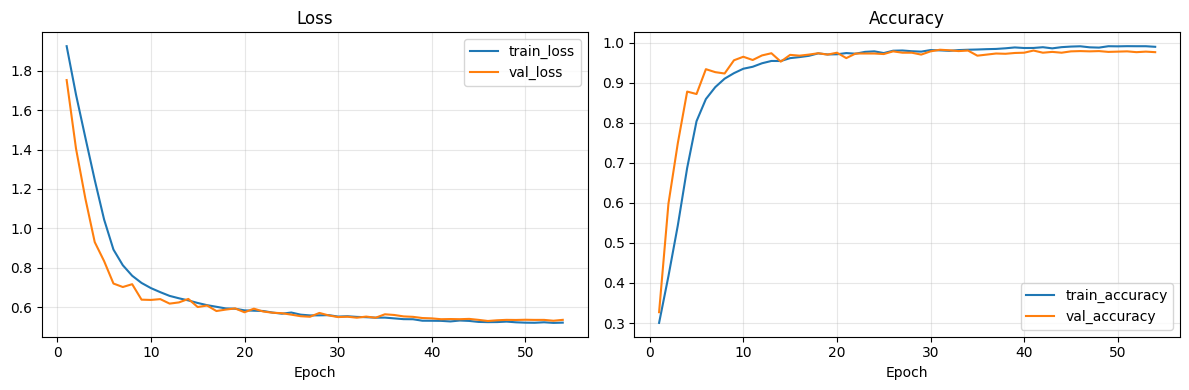

In [12]:
import matplotlib.pyplot as plt
with saved_path("training", "history.csv").open(encoding="utf-8") as stream:
    history = list(csv.DictReader(stream))
epochs = [int(row["epoch"]) for row in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for key in ("train_loss", "val_loss"):
    axes[0].plot(epochs, [float(row[key]) for row in history], label=key)
for key in ("train_accuracy", "val_accuracy"):
    axes[1].plot(epochs, [float(row[key]) for row in history], label=key)
for ax, title in zip(axes, ("Loss", "Accuracy")):
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
(RUN_DIR / "training").mkdir(exist_ok=True)
fig.savefig(RUN_DIR / "training" / "curves.png", dpi=150)
plt.show()


## 8. PyTorch: валидация


Run: /usr/bin/python3 -m ru_kws.evaluate --checkpoint /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/checkpoints/best.pt --data-root /content/ru_kws_data/935326dd48e199342f7d944896a5d0ff22914d02e1507a6b16215eca65925689/russian_commands_v001_clean_manual_with_aug/russian_commands_v001_clean_manual --split val --output /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/measurements/pytorch/val/20260913T160904_008302Z_82ae1ca5/metrics.json
val: kept 1483, dropped 10 commands longer than 3.0s; by label: {'start_timer': 1, 'repeat': 1, 'stop_timer': 7, 'back': 1}
{
  "count": 1483,
  "accuracy": 0.9790964261631827,
  "macro_f1": 0.9829376384050695,
  "per_class": {
    "next": {
      "precision": 0.9933333333333333,
      "recall": 0.9933333333333333,
      "f1": 0.9933333333333333,
      "support": 150
    },
    "back": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 143
    },
    "repeat": {
      "precision": 0.943037974683544

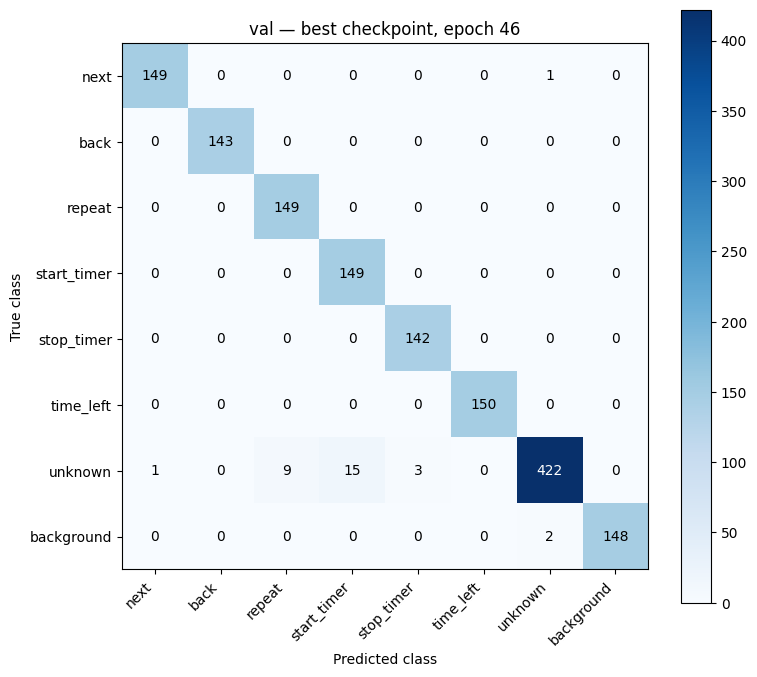

In [13]:
def evaluate_split(split):
    checkpoint = saved_path("checkpoints", "best.pt")
    if not checkpoint.is_file():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint}")
    report_dir = measurement_dir(f"pytorch/{split}")
    output_path = report_dir / "metrics.json"
    run([sys.executable, "-m", "ru_kws.evaluate", "--checkpoint", checkpoint,
         "--data-root", DATA_ROOT, "--split", split, "--output", output_path], cwd=REPO)
    save_measurement(report_dir, "pytorch_clips", {"checkpoint": checkpoint,
        "manifest": DATA_ROOT / "splits" / f"{split}.jsonl"}, split=split,
        dataset_archive_sha256=dataset_archive_hash)
    report = json.loads(output_path.read_text(encoding="utf-8"))
    report["report_dir"] = str(report_dir)
    return report

def show_report(report):
    import numpy as np
    import matplotlib.pyplot as plt
    print(f"Epoch: {report['epoch']} | split: {report['split']} | N={report['count']}")
    print(f"Accuracy: {report['accuracy']:.4f} | macro F1: {report['macro_f1']:.4f}")
    print(f"{'Class':20s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>8s}")
    for name in report["class_order"]:
        row = report["per_class"][name]
        print(f"{name:20s} {row['precision']:10.4f} {row['recall']:10.4f} {row['f1']:10.4f} {row['support']:8d}")
    cm = np.array(report["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    names = report["class_order"]
    ax.set_xticks(range(len(names)), names, rotation=45, ha="right")
    ax.set_yticks(range(len(names)), names)
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha="center", va="center",
                color="white" if value > cm.max() / 2 else "black")
    ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
    ax.set_title(f"{report['split']} — best checkpoint, epoch {report['epoch']}")
    fig.colorbar(im, ax=ax); fig.tight_layout()
    fig.savefig(Path(report["report_dir"]) / "confusion.png", dpi=150)
    plt.show()

val_report = evaluate_split("val")
show_report(val_report)


## 9. PyTorch: финальный тест


In [14]:
if RUN_FINAL_TEST:
    test_report = evaluate_split("test")
    show_report(test_report)
else:
    print("Test skipped.")
print("All results on Drive:", RUN_DIR)


Test skipped.
All results on Drive: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005


## 10. Зависимости TFLite


In [15]:
run([sys.executable, "-m", "pip", "install", "litert-torch", "ai-edge-litert",
     "scipy", "scikit-learn", "tqdm"])


Run: /usr/bin/python3 -m pip install litert-torch ai-edge-litert scipy scikit-learn tqdm
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.3/807.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 459.5/459.5 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 26.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: typing-extens

## 11. Чекпоинт и пути экспорта


In [16]:
from matplotlib import pyplot as plt

import torch
from torch import nn

# Make the freshly installed project visible in the current notebook kernel.
project_src = str(REPO / "src")
if project_src not in sys.path:
    sys.path.insert(0, project_src)

from ru_kws.audio.frontend import build_frontend
from ru_kws.checkpoint import load_checkpoint
from ru_kws.models.factory import build_model

CHECKPOINT_PATH = saved_path("checkpoints", "best.pt")
EXPORT_DIR = RUN_DIR / "exports" / unique_id()
TFLITE_PATH = (Path(EXISTING_TFLITE_PATH) if EXISTING_TFLITE_PATH else
               EXPORT_DIR / "bcresnet_with_frontend_fp32.tflite")
EXPORT_DIR = TFLITE_PATH.parent

checkpoint = load_checkpoint(CHECKPOINT_PATH)
export_config = checkpoint["config"]
export_labels = checkpoint["labels"]
sample_rate = int(export_config["audio"]["sample_rate"])
window_seconds = float(export_config["audio"]["window_seconds"])
num_samples = round(sample_rate * window_seconds)
num_classes = len(export_labels)

classifier = build_model(export_config, num_classes).cpu().float().eval()
classifier.load_state_dict(checkpoint["model_state_dict"], strict=True)
reference_frontend = build_frontend(export_config).cpu().float().eval()
print("Checkpoint:", CHECKPOINT_PATH)
print("Epoch:", checkpoint.get("epoch"))
print("Input shape:", (1, num_samples), "sample rate:", sample_rate)
print("Class order:", sorted(export_labels, key=export_labels.get))


Checkpoint: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/checkpoints/best.pt
Epoch: 46
Input shape: (1, 48000) sample rate: 16000
Class order: ['next', 'back', 'repeat', 'start_timer', 'stop_timer', 'time_left', 'unknown', 'background']


## 12. Frontend для экспорта


In [17]:
import torch.nn.functional as F

class ExportableLogMelFrontend(nn.Module):
    def __init__(self, source_frontend):
        super().__init__()

        mel = source_frontend.mel
        spec = mel.spectrogram

        # Reject settings that this export implementation does not reproduce.
        assert spec.power == 2.0, "Expected a power spectrogram"
        assert spec.normalized is False
        assert spec.onesided is True
        assert spec.center is True
        assert spec.pad_mode == "reflect"
        assert spec.pad == 0

        self.n_fft = spec.n_fft
        self.hop_length = spec.hop_length
        self.n_freqs = self.n_fft // 2 + 1
        self.log_eps = float(getattr(source_frontend, "log_eps", 1e-6))

        # Compute constants in float64, then store float32 filters.
        window = spec.window.detach().cpu().double()
        missing = self.n_fft - window.numel()
        window = F.pad(
            window,
            (missing // 2, missing - missing // 2),
        )

        frequencies = torch.arange(self.n_freqs, dtype=torch.float64)
        samples = torch.arange(self.n_fft, dtype=torch.float64)
        angles = (
            2 * torch.pi
            * frequencies[:, None]
            * samples[None, :]
            / self.n_fft
        )

        real_filters = torch.cos(angles) * window
        imag_filters = -torch.sin(angles) * window

        filters = torch.cat(
            [real_filters, imag_filters], dim=0
        ).unsqueeze(1).float()

        self.register_buffer("dft_filters", filters)

        # [frequency, mel] -> [mel, frequency, 1]
        mel_filters = (
            mel.mel_scale.fb.detach().cpu().float()
            .T.contiguous().unsqueeze(-1)
        )
        self.register_buffer("mel_filters", mel_filters)

    def forward(self, waveforms):
        x = waveforms.unsqueeze(1)  # [B, 1, N]
        x = F.pad(
            x,
            (self.n_fft // 2, self.n_fft // 2),
            mode="reflect",
        )

        spectrum = F.conv1d(
            x, self.dft_filters, stride=self.hop_length
        )
        real = spectrum[:, :self.n_freqs, :]
        imag = spectrum[:, self.n_freqs:, :]

        power = real.square() + imag.square()
        mel = F.conv1d(power, self.mel_filters)

        return torch.log(mel + self.log_eps).unsqueeze(1)



export_frontend = ExportableLogMelFrontend(reference_frontend).eval()


## 13. Проверка эквивалентности frontend


In [18]:
generator = torch.Generator().manual_seed(42)
time_axis = torch.arange(num_samples, dtype=torch.float32) / sample_rate
checks = {
    "silence": torch.zeros(1, num_samples),
    "noise": torch.randn(2, num_samples, generator=generator) * 0.01,
    "tone": (0.1 * torch.sin(2 * torch.pi * 440 * time_axis)).unsqueeze(0),
}

with torch.inference_mode():
    for name, audio in checks.items():
        expected_features = reference_frontend(audio)
        actual_features = export_frontend(audio)
        torch.testing.assert_close(actual_features, expected_features, atol=1e-3, rtol=1e-3)
        expected_logits = classifier(expected_features)
        actual_logits = classifier(actual_features)
        assert expected_logits.shape == (len(audio), num_classes)
        assert torch.isfinite(actual_logits).all()
        torch.testing.assert_close(actual_logits, expected_logits, atol=1e-3, rtol=1e-3)
        print(name, "max feature difference:", (actual_features - expected_features).abs().max().item())
print("Frontend equivalence checks passed.")


silence max feature difference: 0.0
noise max feature difference: 2.384185791015625e-06
tone max feature difference: 0.00028705596923828125
Frontend equivalence checks passed.


## 14. Экспорт TFLite


In [19]:
import litert_torch

class AudioCommandModel(nn.Module):
    def __init__(self, frontend, classifier):
        super().__init__()
        self.frontend = frontend
        self.classifier = classifier

    def forward(self, waveforms):
        return self.classifier(self.frontend(waveforms))

if TFLITE_PATH.exists():
    raise FileExistsError(f"Choose a new TFLITE_PATH: {TFLITE_PATH}")
export_model = AudioCommandModel(export_frontend, classifier).cpu().float().eval()
example_audio = checks["noise"][:1].contiguous()
with torch.no_grad():
    edge_model = litert_torch.convert(export_model, (example_audio,))
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
edge_model.export(str(TFLITE_PATH))
save_measurement(EXPORT_DIR, "tflite_export", {"checkpoint": CHECKPOINT_PATH, "model": TFLITE_PATH},
                 sample_rate=sample_rate, window_seconds=window_seconds, labels=export_labels)
print("Saved:", TFLITE_PATH)


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:04) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:05) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:01)

...

(00:18) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:18) [ DONE] LiteRT-Torch Convert (+00:18)

(00:00) [START] Write Model to 
/content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/exports/20260913T160929_482538Z_9cf8c22a/bcresnet_wit
h_frontend_fp32.tflite

(00:00) [ DONE] Write Model to 
/content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/exports/20260913T160929_482538Z_9cf8c22a/bcresnet_wit
h_frontend_fp32.tflite (+00:00)

Saved: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/exports/20260913T160929_482538Z_9cf8c22a/bcresnet_with_frontend_fp32.tflite


## 15. Проверка экспортированной модели


In [20]:
import numpy as np
from ai_edge_litert.interpreter import Interpreter

interpreter = Interpreter(model_path=str(TFLITE_PATH))
interpreter.allocate_tensors()
inputs = interpreter.get_input_details()
outputs = interpreter.get_output_details()
assert len(inputs) == len(outputs) == 1
input_info, output_info = inputs[0], outputs[0]
assert tuple(input_info["shape"]) == (1, num_samples)
assert tuple(output_info["shape"]) == (1, num_classes)
assert input_info["dtype"] == output_info["dtype"] == np.float32

equivalence = []
with torch.inference_mode():
    for name, batch in checks.items():
        for i in range(len(batch)):
            audio = batch[i:i + 1].contiguous()
            expected = classifier(reference_frontend(audio)).numpy()
            interpreter.set_tensor(input_info["index"], audio.numpy())
            interpreter.invoke()
            actual = interpreter.get_tensor(output_info["index"])
            assert np.isfinite(actual).all()
            np.testing.assert_allclose(actual, expected, atol=1e-3, rtol=1e-3)
            difference = float(np.max(np.abs(expected - actual)))
            equivalence.append({"input": name, "item": i, "max_logit_difference": difference})
            print(f"{name}[{i}]: max logit difference={difference:.6g}")
EQUIVALENCE_DIR = measurement_dir("equivalence")
save_measurement(EQUIVALENCE_DIR, "tflite_equivalence",
    {"checkpoint": CHECKPOINT_PATH, "model": TFLITE_PATH}, atol=1e-3, rtol=1e-3)
(EQUIVALENCE_DIR / "metrics.json").write_text(
    json.dumps({"passed": True, "checks": equivalence}, indent=2, allow_nan=False), encoding="utf-8")
print("Saved TFLite model equivalence checks passed.")


silence[0]: max logit difference=1.13249e-06
noise[0]: max logit difference=3.57628e-07
noise[1]: max logit difference=3.57628e-07
tone[0]: max logit difference=4.58956e-06
Saved TFLite model equivalence checks passed.


## 16. TFLite: оценка на датасете


In [21]:
dataset_labels = json.loads((DATA_ROOT / "labels.json").read_text(encoding="utf-8"))
if dataset_labels != export_labels:
    raise ValueError("Dataset label mapping differs from the checkpoint")
if TFLITE_SPLIT not in {"val", "test"}:
    raise ValueError("Choose val or test for TFLite evaluation")
TFLITE_REPORT_DIR = measurement_dir(f"tflite/{TFLITE_SPLIT}")
run([sys.executable, REPO / "scripts/evaluate_tflite.py",
     "--model", TFLITE_PATH, "--dataset-root", DATA_ROOT,
     "--split", TFLITE_SPLIT, "--sample-rate", sample_rate,
     "--window-seconds", window_seconds, "--long-commands", "skip",
     "--label-smoothing", export_config["training"].get("label_smoothing", 0.0),
     "--output-dir", TFLITE_REPORT_DIR], cwd=REPO)
print("TFLite reports:", TFLITE_REPORT_DIR)

save_measurement(TFLITE_REPORT_DIR, "tflite_clips",
    {"checkpoint": CHECKPOINT_PATH, "model": TFLITE_PATH,
     "manifest": DATA_ROOT / "splits" / f"{TFLITE_SPLIT}.jsonl"},
    split=TFLITE_SPLIT, dataset_archive_sha256=dataset_archive_hash)


Run: /usr/bin/python3 /content/ru-kws-tbpe0nmn/scripts/evaluate_tflite.py --model /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/exports/20260913T160929_482538Z_9cf8c22a/bcresnet_with_frontend_fp32.tflite --dataset-root /content/ru_kws_data/935326dd48e199342f7d944896a5d0ff22914d02e1507a6b16215eca65925689/russian_commands_v001_clean_manual_with_aug/russian_commands_v001_clean_manual --split val --sample-rate 16000 --window-seconds 3.0 --long-commands skip --label-smoothing 0.1 --output-dir /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/measurements/tflite/val/20260913T160957_824894Z_071646ab
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
Input: [    1 48000] <class 'numpy.float32'>
Output: [1 8] <class 'numpy.float32'>

TFLite validation: 100%|██████████| 1493/1493 [00:46<00:00, 32.17it/s]

Evaluated: 1483/1493; processing: {'padded': 1463, 'cropped': 20, 'skipped_long': 10}
Loss: 0.529060; Accuracy: 0.979096
              precision    recall  f1-s

## 17. TFLite: отдельные записи диктофона


In [22]:
import json
from pathlib import Path
from collections import Counter

RECORDINGS, recordings_archive_hash = extract_cached(
    RECORDINGS_ZIP,
    Path("/content/real_recordings"),
)
print("Recordings:", RECORDINGS)


Unpacking 132 files...
Recordings: /content/real_recordings/260d46ad6c78327a4599fc8440d41a6da0eec7c4b4fae8beb0cb1bc458bfddcf


In [23]:
import json
from pathlib import Path
from collections import Counter

rows = []
for manifest in sorted(RECORDINGS.rglob("manifest.jsonl")):
    for line in manifest.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        row = json.loads(line)
        if row.get("accepted") is not True or row.get("error"):
            continue

        wav = manifest.parent / row["wav"]
        if not wav.is_file():
            raise FileNotFoundError(wav)
        if row["label"] not in export_labels:
            raise ValueError(f"Unknown label: {row['label']}")

        rows.append({
            "path": wav.relative_to(RECORDINGS).as_posix(),
            "label": row["label"],
        })

if not rows:
    raise ValueError("No accepted recordings found; check RECORDINGS")

# Temporary evaluation metadata; original recordings remain unchanged.
EVAL_META = Path("/content/recorder_eval")
EVAL_META.mkdir(exist_ok=True)

(EVAL_META / "clips.jsonl").write_text(
    "".join(json.dumps(row, ensure_ascii=False) + "\n" for row in rows),
    encoding="utf-8",
)
(EVAL_META / "labels.json").write_text(
    json.dumps(export_labels, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Clips:", len(rows))
print(Counter(row["label"] for row in rows))


Clips: 60
Counter({'repeat': 10, 'time_left': 10, 'next': 10, 'stop_timer': 10, 'back': 10, 'start_timer': 10})


In [24]:
from datetime import datetime

REPORT_DIR = measurement_dir("recorder_clips")

run([
    sys.executable, str(REPO / "scripts/evaluate_tflite.py"),
    "--model", str(TFLITE_PATH),
    "--dataset-root", str(RECORDINGS),
    "--manifest", str(EVAL_META / "clips.jsonl"),
    "--labels", str(EVAL_META / "labels.json"),
    "--split", "test",
    "--sample-rate", str(sample_rate),
    "--window-seconds", str(window_seconds),
    "--resample",
    "--long-commands", "skip",
    "--output-kind", "logits",
    "--label-smoothing", "0",
    "--output-dir", str(REPORT_DIR),
])

save_measurement(REPORT_DIR, "recorder_clips", {"checkpoint": CHECKPOINT_PATH,
    "model": TFLITE_PATH, "manifest": EVAL_META / "clips.jsonl"},
    archive_sha256=recordings_archive_hash)
for name in ("clips.jsonl", "labels.json"):
    (REPORT_DIR / name).write_bytes((EVAL_META / name).read_bytes())
print("Results:", REPORT_DIR)


Run: /usr/bin/python3 /content/ru-kws-tbpe0nmn/scripts/evaluate_tflite.py --model /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/exports/20260913T160929_482538Z_9cf8c22a/bcresnet_with_frontend_fp32.tflite --dataset-root /content/real_recordings/260d46ad6c78327a4599fc8440d41a6da0eec7c4b4fae8beb0cb1bc458bfddcf --manifest /content/recorder_eval/clips.jsonl --labels /content/recorder_eval/labels.json --split test --sample-rate 16000 --window-seconds 3.0 --resample --long-commands skip --output-kind logits --label-smoothing 0 --output-dir /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/measurements/recorder_clips/20260913T161050_297635Z_19daa91c
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
Input: [    1 48000] <class 'numpy.float32'>
Output: [1 8] <class 'numpy.float32'>

TFLite validation: 100%|██████████| 60/60 [00:01<00:00, 30.01it/s]

Evaluated: 60/60; processing: {'resampled': 60, 'padded': 60}
Loss: 0.214734; Accuracy: 0.983333
              pre

In [25]:
run([sys.executable, "-m", "pip", "install", "pandas"])
import pandas as pd

display(pd.read_csv(
    REPORT_DIR / "confusion_matrix.csv",
    index_col=0,
))

predictions = pd.read_csv(REPORT_DIR / "predictions.csv")
display(predictions.loc[
    predictions["correct"] == 0,
    ["path", "true_label", "predicted_label"]
])


Run: /usr/bin/python3 -m pip install pandas


,next,back,repeat,start_timer,stop_timer,time_left,unknown,background
true / predicted,,,,,,,,
next,9,0,0,0,0,0,0,1
back,0,10,0,0,0,0,0,0
repeat,0,0,10,0,0,0,0,0
start_timer,0,0,0,10,0,0,0,0
stop_timer,0,0,0,0,10,0,0,0
time_left,0,0,0,0,0,10,0,0
unknown,0,0,0,0,0,0,0,0
background,0,0,0,0,0,0,0,0


,path,true_label,predicted_label
35,recordings/20260912_233902_49b76bc1/0036_next_...,next,background


In [26]:
df = pd.read_csv(REPORT_DIR / "predictions.csv")

df["confidence"] = [
    row[f"p_{row['predicted_label']}"]
    for _, row in df.iterrows()
]
df["true_class_probability"] = [
    row[f"p_{row['true_label']}"]
    for _, row in df.iterrows()
]

columns = [
    "path", "true_label", "predicted_label",
    "confidence", "true_class_probability",
    "p_unknown", "p_background",
]

display(
    df[columns].style.format({
        "confidence": "{:.1%}",
        "true_class_probability": "{:.1%}",
        "p_unknown": "{:.1%}",
        "p_background": "{:.1%}",
    })
)


,path,true_label,predicted_label,confidence,true_class_probability,p_unknown,p_background
0,recordings/20260912_233902_49b76bc1/0001_repeat_b1a8fad7.wav,repeat,repeat,59.9%,59.9%,0.3%,31.8%
1,recordings/20260912_233902_49b76bc1/0002_time_left_6488f4c8.wav,time_left,time_left,92.7%,92.7%,0.0%,5.8%
2,recordings/20260912_233902_49b76bc1/0003_next_9a41dfff.wav,next,next,88.4%,88.4%,0.5%,5.7%
3,recordings/20260912_233902_49b76bc1/0004_time_left_1355e2e5.wav,time_left,time_left,95.0%,95.0%,0.1%,4.1%
4,recordings/20260912_233902_49b76bc1/0005_stop_timer_692d31b6.wav,stop_timer,stop_timer,70.0%,70.0%,1.6%,17.0%
5,recordings/20260912_233902_49b76bc1/0006_repeat_b2898fa5.wav,repeat,repeat,78.6%,78.6%,0.5%,12.6%
6,recordings/20260912_233902_49b76bc1/0007_back_647f6382.wav,back,back,87.2%,87.2%,0.4%,6.0%
7,recordings/20260912_233902_49b76bc1/0008_stop_timer_6fc0a04e.wav,stop_timer,stop_timer,90.3%,90.3%,1.1%,6.7%
8,recordings/20260912_233902_49b76bc1/0009_start_timer_2204fe15.wav,start_timer,start_timer,93.5%,93.5%,0.2%,4.2%
9,recordings/20260912_233902_49b76bc1/0010_back_dc930efb.wav,back,back,89.8%,89.8%,0.2%,5.0%


## 18. Длинная запись: аудио и разметка


In [27]:
run([sys.executable, "-m", "pip", "install", "ai-edge-litert", "scipy", "tqdm", "pandas", "matplotlib"])
CHECKPOINT_PATH = saved_path("checkpoints", "best.pt")
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
if checkpoint.get("format_version") != 1:
    raise ValueError("Unsupported checkpoint format")
# EXISTING_TFLITE_PATH allows this section to run without export cells.
if EXISTING_TFLITE_PATH:
    TFLITE_PATH = Path(EXISTING_TFLITE_PATH)
if "TFLITE_PATH" not in globals() or not TFLITE_PATH.is_file():
    raise FileNotFoundError("Export the model or set EXISTING_TFLITE_PATH")
labels = checkpoint["labels"]
sample_rate = int(checkpoint["config"]["audio"]["sample_rate"])
window_seconds = float(checkpoint["config"]["audio"]["window_seconds"])
RECORDINGS, archive_hash = extract_cached(RECORDINGS_ZIP, Path("/content/real_recordings"))
if CONTINUOUS_WAV:
    WAV = (RECORDINGS / CONTINUOUS_WAV).resolve()
    if not WAV.is_relative_to(RECORDINGS.resolve()) or not WAV.is_file():
        raise ValueError("CONTINUOUS_WAV must select a file inside the extracted archive")
else:
    candidates = sorted(RECORDINGS.rglob("continuous.wav"))
    if len(candidates) != 1:
        raise ValueError(f"Set CONTINUOUS_WAV to a relative path: {[str(p.relative_to(RECORDINGS)) for p in candidates]}")
    WAV = candidates[0]
reviewed = WAV.with_name(WAV.stem + ".reviewed.json")
ANNOTATIONS = reviewed if reviewed.exists() else WAV.with_suffix(".json")
LABELS = Path("/content/continuous_labels.json")
LABELS.write_text(json.dumps(labels, ensure_ascii=False, indent=2), encoding="utf-8")
print("Model:", TFLITE_PATH)
print("WAV:", WAV)
print("Annotations:", ANNOTATIONS)


Run: /usr/bin/python3 -m pip install ai-edge-litert scipy tqdm pandas matplotlib
Use unziped archive: /content/real_recordings/260d46ad6c78327a4599fc8440d41a6da0eec7c4b4fae8beb0cb1bc458bfddcf
Model: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/exports/20260913T160929_482538Z_9cf8c22a/bcresnet_with_frontend_fp32.tflite
WAV: /content/real_recordings/260d46ad6c78327a4599fc8440d41a6da0eec7c4b4fae8beb0cb1bc458bfddcf/recordings/20260912_234712_7f0605c7/continuous.wav
Annotations: /content/real_recordings/260d46ad6c78327a4599fc8440d41a6da0eec7c4b4fae8beb0cb1bc458bfddcf/recordings/20260912_234712_7f0605c7/continuous.json


## 19. Длинная запись: запуск измерения


In [28]:
REPORT_DIR = measurement_dir("continuous")
command = [sys.executable, str(REPO / 'scripts/evaluate_continuous_tflite.py'),
    '--model', str(TFLITE_PATH), '--wav', str(WAV), '--annotations', str(ANNOTATIONS),
    '--labels', str(LABELS), '--output-dir', str(REPORT_DIR),
    '--sample-rate', str(sample_rate), '--window-seconds', str(window_seconds),
    '--hop-seconds', str(HOP_SECONDS), '--resample', '--output-kind', 'logits',
    '--threshold', str(THRESHOLD), '--min-consecutive', str(MIN_CONSECUTIVE),
    '--release-seconds', str(RELEASE_SECONDS), '--cooldown-seconds', str(COOLDOWN_SECONDS),
    '--early-tolerance', str(EARLY_TOLERANCE), '--late-tolerance', str(LATE_TOLERANCE),
    '--print-predictions']
if ALLOW_DRAFT:
    command.append('--allow-draft')
run(command, cwd=REPO)
print('Saved to Drive:', REPORT_DIR)

save_measurement(REPORT_DIR, "continuous_tflite", {"checkpoint": CHECKPOINT_PATH,
    "model": TFLITE_PATH, "wav": WAV, "annotations": ANNOTATIONS},
    archive_sha256=archive_hash, threshold=THRESHOLD, hop_seconds=HOP_SECONDS,
    min_consecutive=MIN_CONSECUTIVE, release_seconds=RELEASE_SECONDS,
    cooldown_seconds=COOLDOWN_SECONDS, early_tolerance=EARLY_TOLERANCE,
    late_tolerance=LATE_TOLERANCE, allow_draft=ALLOW_DRAFT)


Run: /usr/bin/python3 /content/ru-kws-tbpe0nmn/scripts/evaluate_continuous_tflite.py --model /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/exports/20260913T160929_482538Z_9cf8c22a/bcresnet_with_frontend_fp32.tflite --wav /content/real_recordings/260d46ad6c78327a4599fc8440d41a6da0eec7c4b4fae8beb0cb1bc458bfddcf/recordings/20260912_234712_7f0605c7/continuous.wav --annotations /content/real_recordings/260d46ad6c78327a4599fc8440d41a6da0eec7c4b4fae8beb0cb1bc458bfddcf/recordings/20260912_234712_7f0605c7/continuous.json --labels /content/continuous_labels.json --output-dir /content/drive/MyDrive/russian_commands/runs/bcresnet_run_005/measurements/continuous/20260913T161105_124889Z_de06b48a --sample-rate 16000 --window-seconds 3.0 --hop-seconds 0.1 --resample --output-kind logits --threshold 0.5 --min-consecutive 2 --release-seconds 0.3 --cooldown-seconds 1.0 --early-tolerance 0.0 --late-tolerance 1.0 --print-predictions --allow-draft
INFO: Created TensorFlow Lite XNNPACK delega

## 20. Длинная запись: метрики и временная шкала


PROVISIONAL: True


,value
tp,26.000000
fp,3.000000
fn,3.000000
precision,0.896552
recall,0.896552
f1,0.896552
unmatched_detections_per_hour_full_recording,99.028058
median_latency_seconds,-0.310000


FP/hour: вся длительность записи. Задержка: от конца фразы, без времени вычислений.


,true_events,detections,tp,fp,fn,precision,recall,f1,unmatched_detections_per_hour_full_recording,median_latency_seconds,p95_latency_seconds
next,5.0,5.0,5.0,0.0,0.0,1.0,1.0,1.000000,0.000000,-0.32,-0.204
back,5.0,5.0,5.0,0.0,0.0,1.0,1.0,1.000000,0.000000,0.16,0.244
repeat,5.0,4.0,4.0,0.0,1.0,1.0,0.8,0.888889,0.000000,-0.06,0.261
start_timer,5.0,5.0,4.0,1.0,1.0,0.8,0.8,0.800000,33.009353,-0.32,-0.246
stop_timer,5.0,5.0,4.0,1.0,1.0,0.8,0.8,0.800000,33.009353,-0.42,-0.303
time_left,4.0,5.0,4.0,1.0,0.0,0.8,1.0,0.888889,33.009353,-0.36,-0.099


,label,start_seconds,end_seconds,event_id,detection_id,confidence,latency_seconds
0,next,5.620000,7.340000,0,0.000000,90.8%,-0.740
1,back,12.780000,14.340000,1,1.000000,79.0%,-0.640
2,repeat,16.500000,18.220000,2,2.000000,76.8%,-0.720
3,start_timer,21.580000,23.260000,3,3.000000,94.1%,-0.360
4,stop_timer,25.860000,27.420000,4,4.000000,76.5%,-0.320
5,time_left,29.300000,30.900000,5,5.000000,75.0%,-0.500
6,next,33.140000,34.220000,6,6.000000,87.8%,-0.220
7,back,35.380000,36.340000,7,7.000000,53.0%,0.160
8,repeat,37.700000,38.860000,8,8.000000,88.8%,0.040
9,start_timer,40.500000,41.780000,9,9.000000,90.4%,-0.280


,label,time_seconds,confidence,detection_id,event_id,latency_seconds
0,next,6.600000,90.8%,0,0.000000,-0.740
1,back,13.700000,79.0%,1,1.000000,-0.640
2,repeat,17.500000,76.8%,2,2.000000,-0.720
3,start_timer,22.900000,94.1%,3,3.000000,-0.360
4,stop_timer,27.100000,76.5%,4,4.000000,-0.320
5,time_left,30.400000,75.0%,5,5.000000,-0.500
6,next,34.000000,87.8%,6,6.000000,-0.220
7,back,36.500000,53.0%,7,7.000000,0.160
8,repeat,38.900000,88.8%,8,8.000000,0.040
9,start_timer,41.500000,90.4%,9,9.000000,-0.280


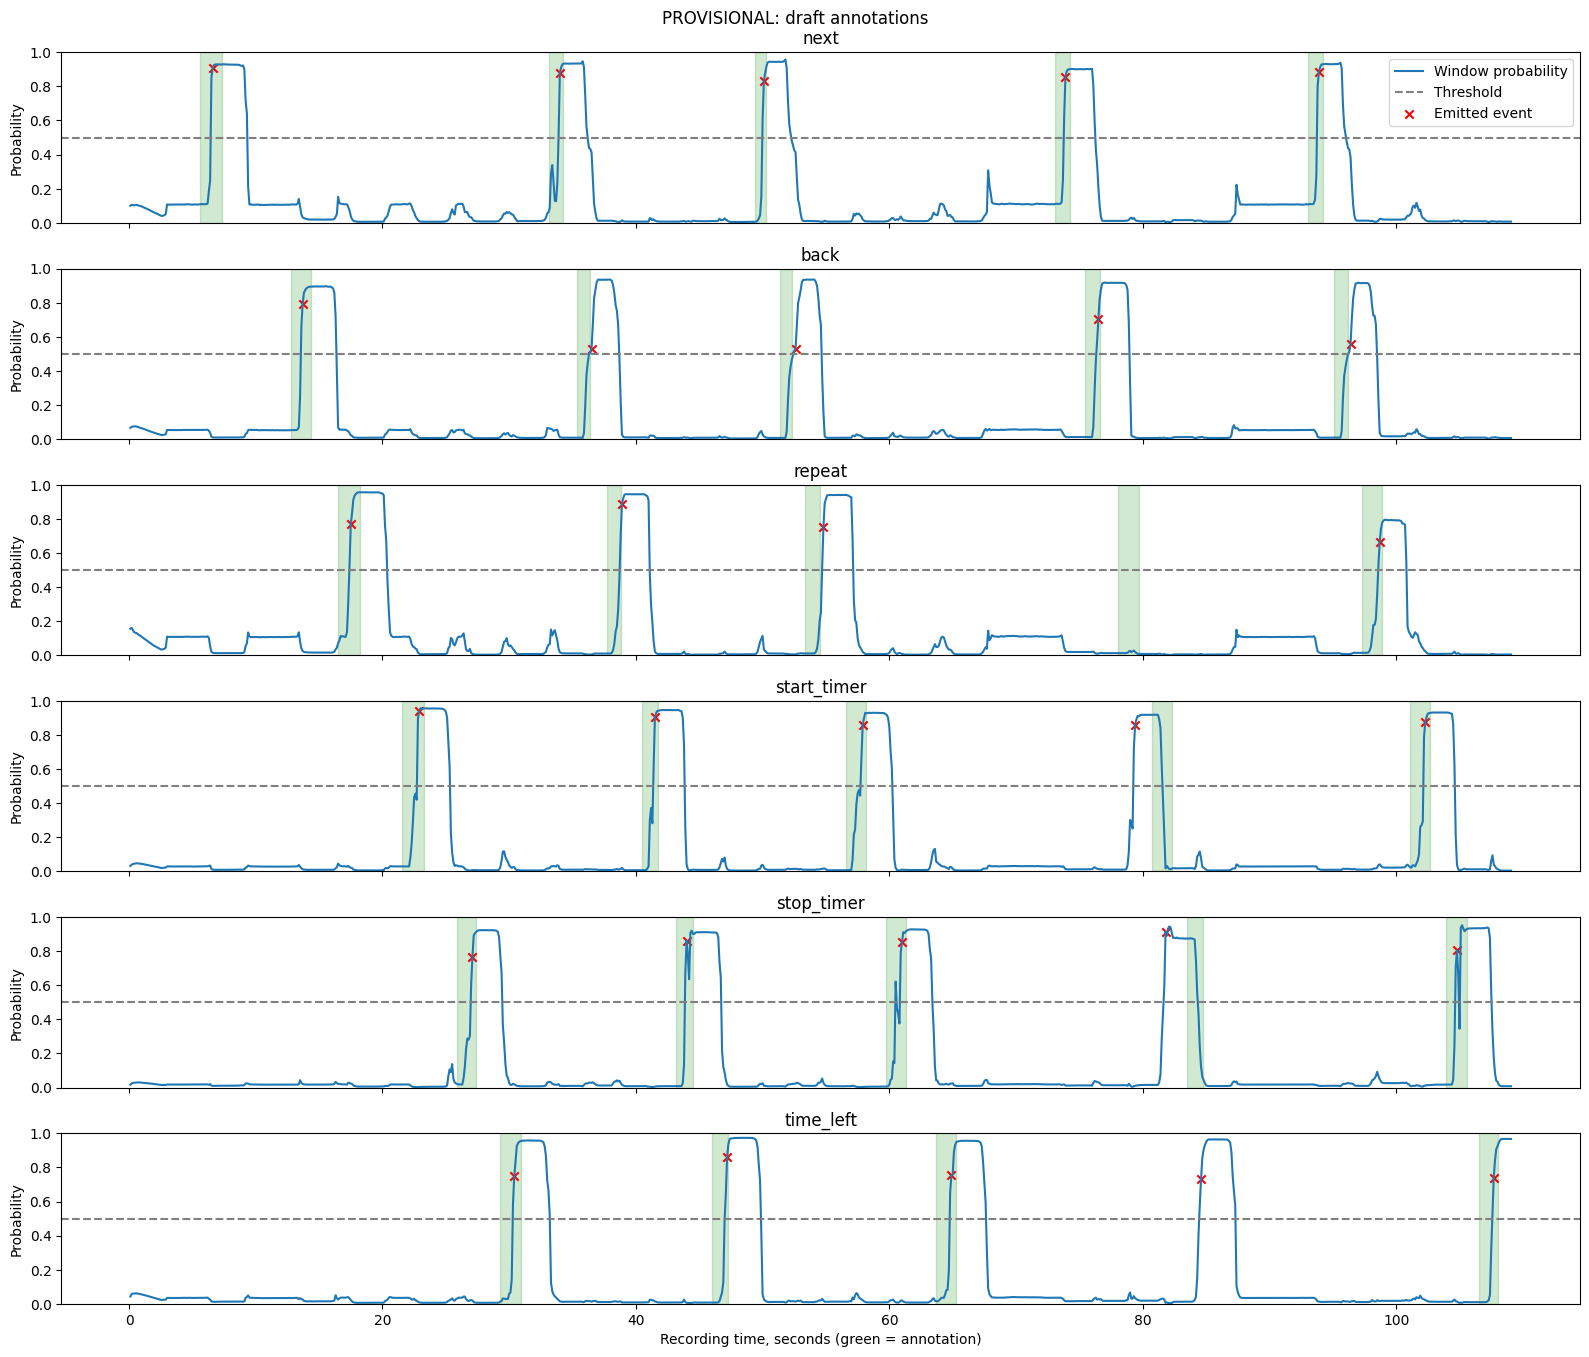

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = json.loads((REPORT_DIR / 'metrics.json').read_text(encoding='utf-8'))
print('PROVISIONAL:', metrics['provisional'])
display(pd.Series({key: metrics[key] for key in ["tp", "fp", "fn", "precision", "recall", "f1",
    "unmatched_detections_per_hour_full_recording", "median_latency_seconds"]}, name="value"))
print("FP/hour: вся длительность записи. Задержка: от конца фразы, без времени вычислений.")
display(pd.DataFrame(metrics['per_class']).T)
events = pd.read_csv(REPORT_DIR / 'events.csv')
detections = pd.read_csv(REPORT_DIR / 'detections.csv')
windows = pd.read_csv(REPORT_DIR / 'windows.csv')
display(events.style.format({'confidence': '{:.1%}', 'latency_seconds': '{:.3f}'}, na_rep='missed'))
display(detections.style.format({'confidence': '{:.1%}', 'latency_seconds': '{:.3f}'}, na_rep='unmatched'))

commands = list(metrics['per_class'])
fig, axes = plt.subplots(len(commands), 1, figsize=(16, 2.3 * len(commands)), sharex=True, squeeze=False)
for ax, label in zip(axes[:, 0], commands):
    ax.plot(windows.end_seconds, windows['p_' + label], label='Window probability')
    ax.axhline(metrics['config']['threshold'], color='gray', linestyle='--', label='Threshold')
    for event in events[events.label == label].itertuples():
        ax.axvspan(event.start_seconds, event.end_seconds, color='green', alpha=.18)
    selected = detections[detections.label == label]
    ax.scatter(selected.time_seconds, selected.confidence, marker='x', color='red', label='Emitted event')
    ax.set(title=label, ylim=(0, 1), ylabel='Probability')
axes[0, 0].legend(loc='upper right')
axes[-1, 0].set_xlabel('Recording time, seconds (green = annotation)')
fig.suptitle('PROVISIONAL: draft annotations' if metrics['provisional'] else 'Continuous evaluation')
fig.tight_layout()
fig.savefig(REPORT_DIR / 'timeline.png', dpi=150)
plt.show()
